In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


# 1. Load the dataset

In [33]:
df = pd.read_csv("prabhsimrat_logs.csv")


In [34]:
df

,timestamp,cpuUsage,cpuTemperature,ramUsage,networkConnections,processCount,cpuPackagePower,cpuAverageClock
0,2026-07-01 02:30:53.975169600,27.4,82.9,71.33,236,269,31.3,3169
1,2026-07-01 02:30:57.909829600,8.3,71.3,71.70,237,269,15.3,3860
2,2026-07-01 02:31:00.960654700,15.5,75.0,71.64,239,270,21.4,4261
3,2026-07-01 02:31:03.999124400,43.9,85.6,71.67,236,270,41.5,3829
4,2026-07-01 02:31:07.045752800,49.6,91.9,72.76,238,270,42.9,3677
...,...,...,...,...,...,...,...,...
16356,2026-07-02 08:16:42.986522700,83.7,73.5,63.37,210,309,55.2,4217
16357,2026-07-02 08:16:44.590380900,99.9,82.1,64.12,268,307,58.5,4217
16358,2026-07-02 08:16:46.139693100,99.9,82.1,63.86,241,303,58.5,4214
16359,2026-07-02 08:16:47.673560300,21.6,79.0,63.57,271,305,29.6,3980


# 2. Selecting the features and target variables

We exclude the timestamp from training but keep it ordered sequentially

In [35]:
feature_cols = ['cpuUsage', 'ramUsage', 'networkConnections', 'processCount', 'cpuPackagePower', 'cpuAverageClock']
target_col = 'cpuTemperature'

# 3. Scale the data independently to prevent data leakage

In [36]:
scaler_X = MinMaxScaler(feature_range=(0,1))
scaler_Y = MinMaxScaler(feature_range=(0,1))

scaled_X = scaler_X.fit_transform(df[feature_cols])
scaled_Y = scaler_Y.fit_transform(df[[target_col]])

# 4. Create the sequence windows

In [37]:
def create_dataset(X_data, y_data, lookback = 10):
    X,y = [], []
    for i in range(len(X_data)-lookback):
        X.append(X_data[i: i+lookback])
        y.append(y_data[i+lookback])
        
    return np.array(X), np.array(y)

Lets lookback at the last 15 log entries to predict the next temperature step

In [38]:
lookback_window = 15
X,y = create_dataset(scaled_X, scaled_Y, lookback = lookback_window)

# 5. Split the dataset into Test/train sequentially, We cannot shuffle time series data randomly

In [39]:
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape} ")
print(f"y_train shape: {y_train.shape} ")

X_train shape: (13076, 15, 6) 
y_train shape: (13076, 1) 


# 6. Build the Regression LSTM Model

In [40]:
model = Sequential()

# First LSTM Layer: input shape requires (window_size, num_features)
model.add(LSTM(64, return_sequences=True, input_shape= (X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) #to prevent overfitting

# Second LSTM Layer
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Dense Output Layer: 1 node for predicting a continuous temperature value
model.add(Dense(1))

# Compile using Mean Squared Error (standard for numeric regression)
model.compile(loss= 'mean_squared_error', optimizer = "adam", metrics = ['mae'])
model.summary()

/media/rehnoor/48984F97984F8284/Learning LSTM/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 15, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Train the Model

In [41]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0210 - mae: 0.1021 - val_loss: 0.0063 - val_mae: 0.0528
Epoch 2/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0095 - mae: 0.0750 - val_loss: 0.0046 - val_mae: 0.0407
Epoch 3/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0079 - mae: 0.0675 - val_loss: 0.0036 - val_mae: 0.0287
Epoch 4/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0068 - mae: 0.0621 - val_loss: 0.0046 - val_mae: 0.0432
Epoch 5/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0060 - mae: 0.0578 - val_loss: 0.0033 - val_mae: 0.0255
Epoch 6/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0051 - mae: 0.0527 - val_loss: 0.0031 - val_mae: 0.0244
Epoch 7/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0046 - mae: 0.0490 - val_loss: 0.0031 - val_mae: 0.0227
Epoch 8/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0039 - mae: 0.0448 - val_loss: 0.0030 - val_mae: 0.0243
Epoch 9/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms

Evaluating the model

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [43]:
# Step 1: Generate predictions on the test set
y_pred_scaled = model.predict(X_test)

# Step 2: Reverse the scaling transformation
y_pred = scaler_Y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_Y.inverse_transform(y_test) # No reshape tricks needed!

# Step 3: Compute Evaluation Metrics
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("----Test Set Performance----")
print(f"Mean Absolute Error (MAE): {mae:.2f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °C")
print(f"R² Score (Variance Explained): {r2:.4f}")

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
----Test Set Performance----
Mean Absolute Error (MAE): 2.02 °C
Root Mean Squared Error (RMSE): 5.14 °C
R² Score (Variance Explained): 0.8045


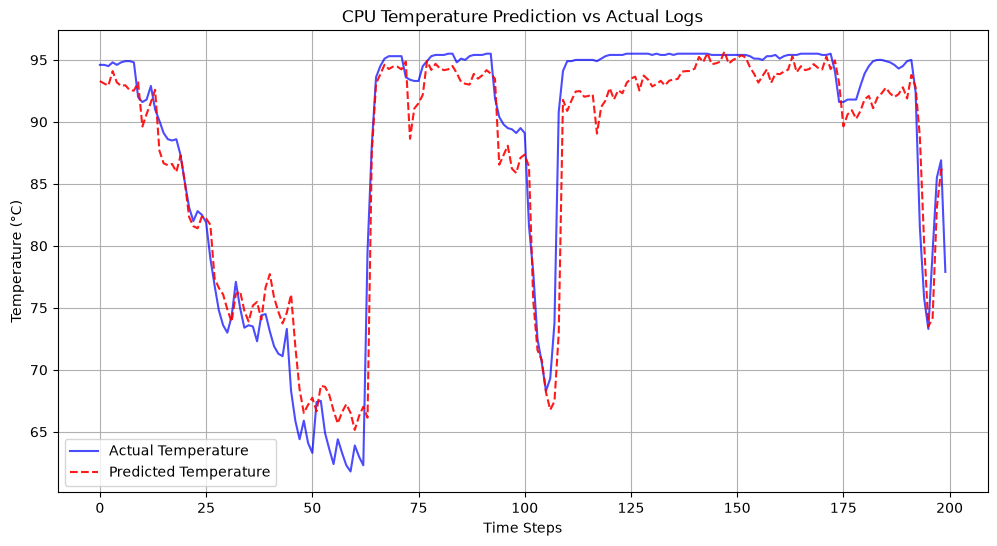

In [44]:
# Step 4: Plot Actual vs Predicted Temperature (First 200 points for clarity)
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual[:200], label='Actual Temperature', color='blue', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Temperature', color='red', linestyle='--', alpha=0.9)
plt.title('CPU Temperature Prediction vs Actual Logs')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()